In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = '/Users/sasaatlasov/Desktop/data_demo' + '/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=16)

In [3]:
for i in val_loader:
    energy = i[0]
    point = i[1][0]
    momentum = i[1][1]
    print(i[0].shape)
    print(i[1][0].shape)
    print(i[1][1].shape)
    break

torch.Size([16, 1, 30, 30])
torch.Size([16, 2])
torch.Size([16, 3])


In [4]:
from diffusion import DiffusionModel
from unet_small import UnetModel

model = UnetModel(1, 1, 16)
dm = DiffusionModel(model, 'l2', (1e-4, 0.02), 1000)
dm.load_state_dict(torch.load('checkpoints/second_small_161000.pt', map_location=torch.device('cpu')))
dm.eval();

  0%|          | 0/3750 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

9it [01:02,  6.92s/it]


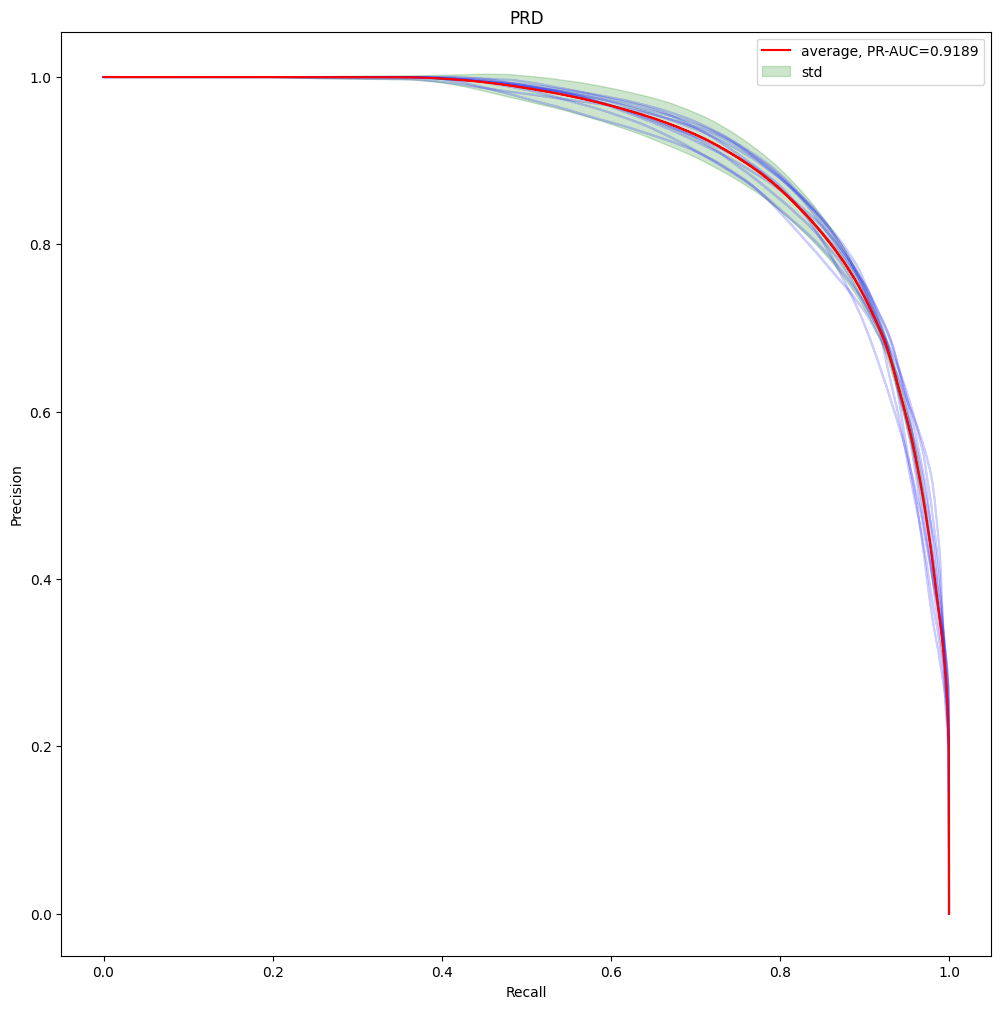

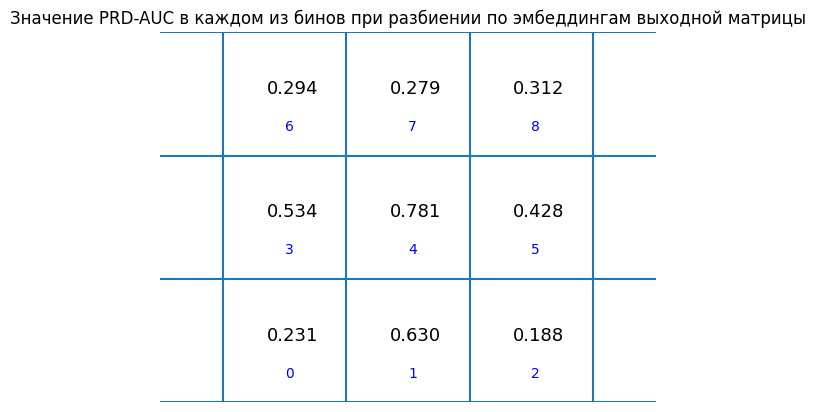

(0.9188709048400454, 0.408398406752715)

In [29]:
from evaluate import calc_metrics

calc_metrics(dm, val_loader, 50)

In [5]:
dm.eval()
with torch.no_grad():
    samples = dm.sample(momentum, point, (1, 30, 30))

  0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
from scipy.linalg import sqrtm
from tqdm.auto import tqdm
from collections import defaultdict
from metrics.calogan_prd import embedder

def get_representations(data, encoder, device):
    representations = []
    ### BEGIN SOLUTION
    for image in data:
        with torch.no_grad():
            image = image.to(device)
            representations.append(encoder.get_encoding(image.view(-1, 1, 30, 30)).view(-1, ))
    ### END SOLUTION
    return representations

def calculate_fid(repr1, repr2):
    ### BEGIN SOLUTION
    mean1 = np.mean(repr1, axis=0)
    mean2 = np.mean(repr2, axis=0)

    cov1 = np.cov(repr1, rowvar=False)
    cov2 = np.cov(repr2, rowvar=False)

    sqrt_matrix = sqrtm(cov1 @ cov2).real
    return np.sum((mean1 - mean2) ** 2) + np.trace(cov1 + cov2 - 2 * sqrt_matrix)

In [10]:
real = get_representations(energy, embedder, 'cpu')
fake = get_representations(samples, embedder, 'cpu')

print('FID:', calculate_fid(real, fake))

FID: 0.39849427301738394


In [11]:
def compare(idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())

    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    if truncate:
        sampled[sampled < truncate] = 0
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

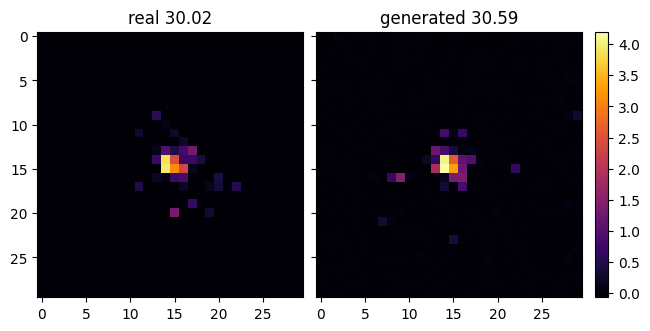

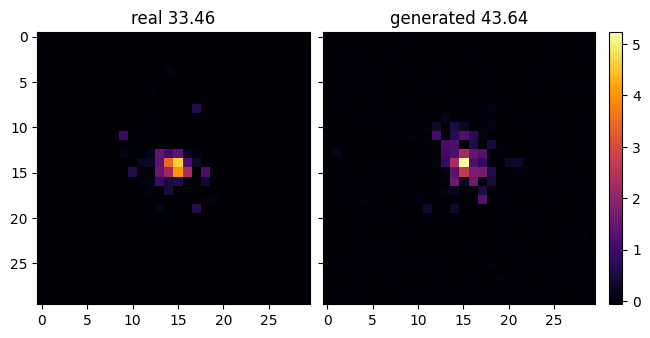

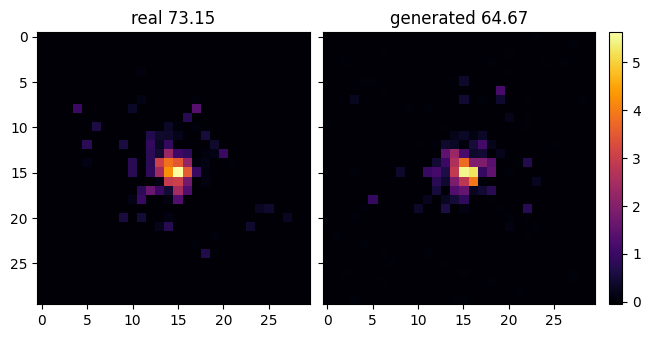

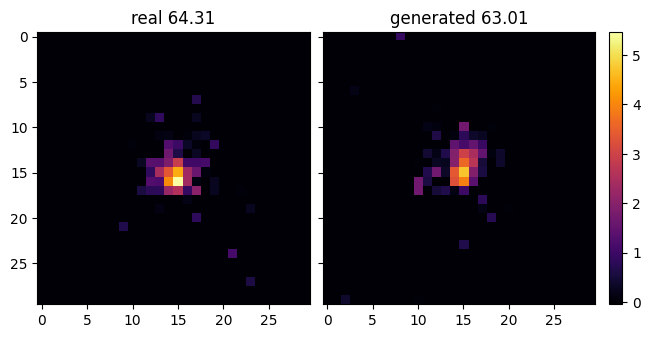

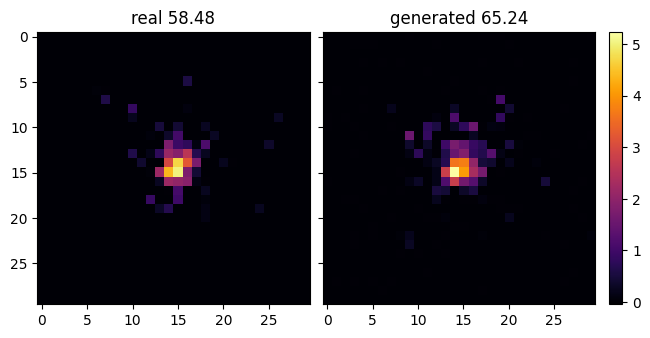

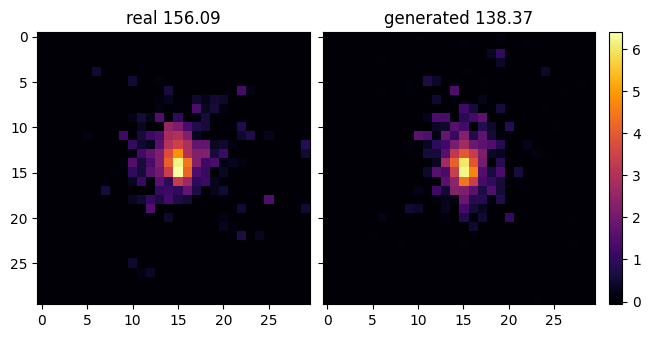

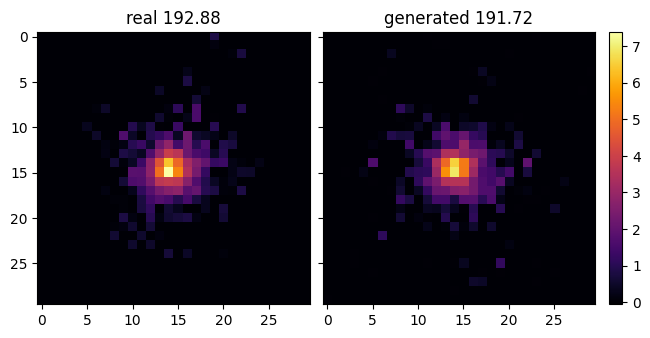

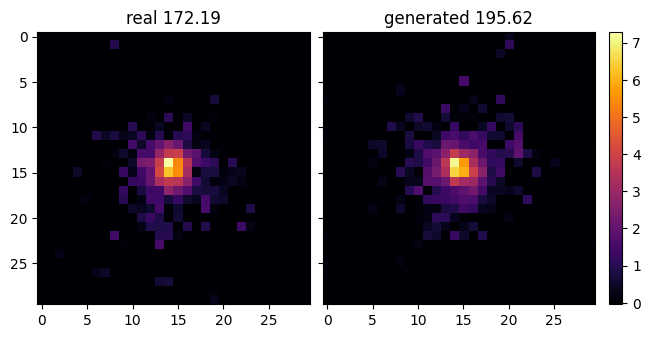

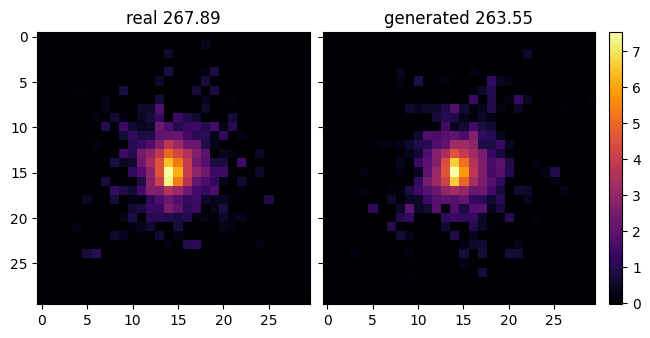

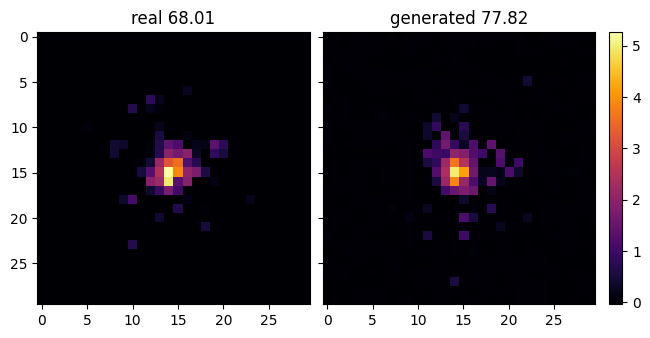

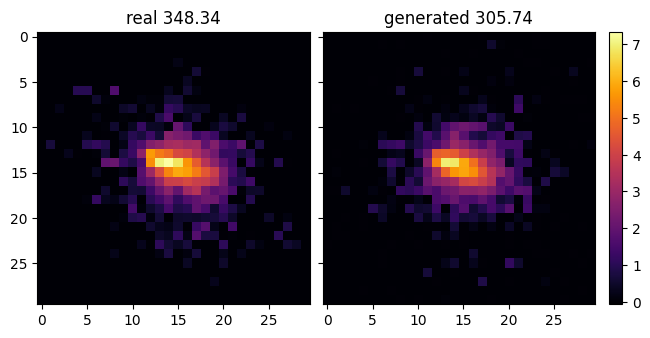

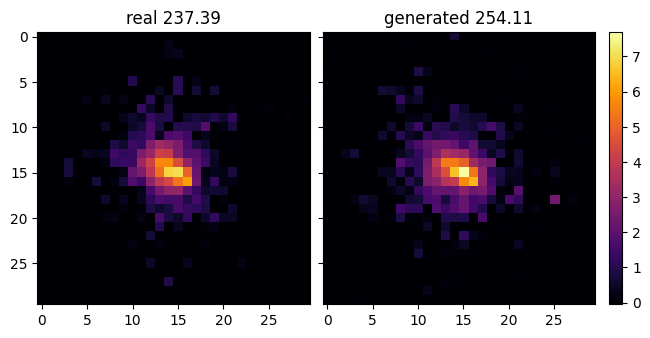

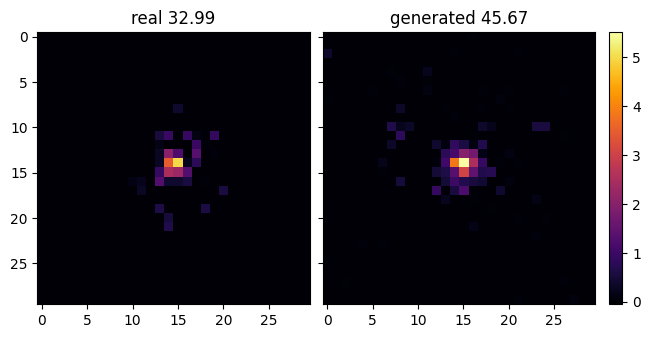

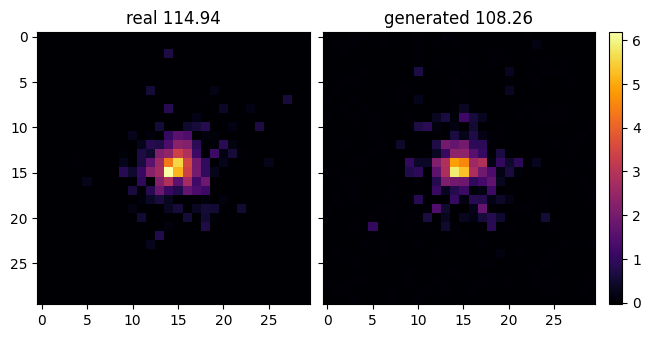

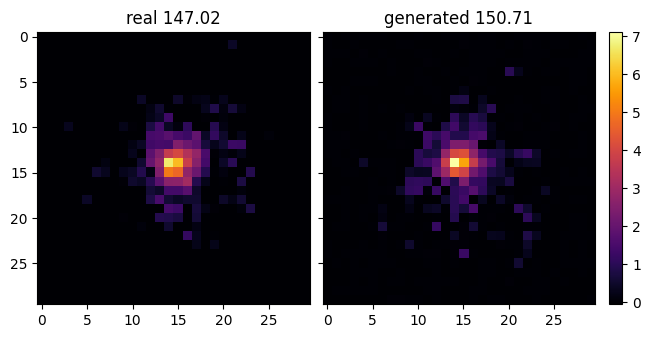

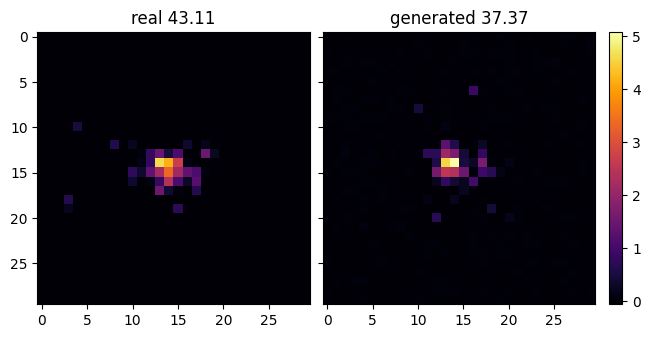

In [13]:
for i in range(16):
    compare(i, 1e-6)